# Metadata examples for instances from the dataset

We fill first have a look at one of the smaller instances, a MERA network used in quantum phyisics. Afterwards there is an example with three independent components.


## MERA

We load the instance `str_nw_mera_open_26` and plot it using `cotengra`. 

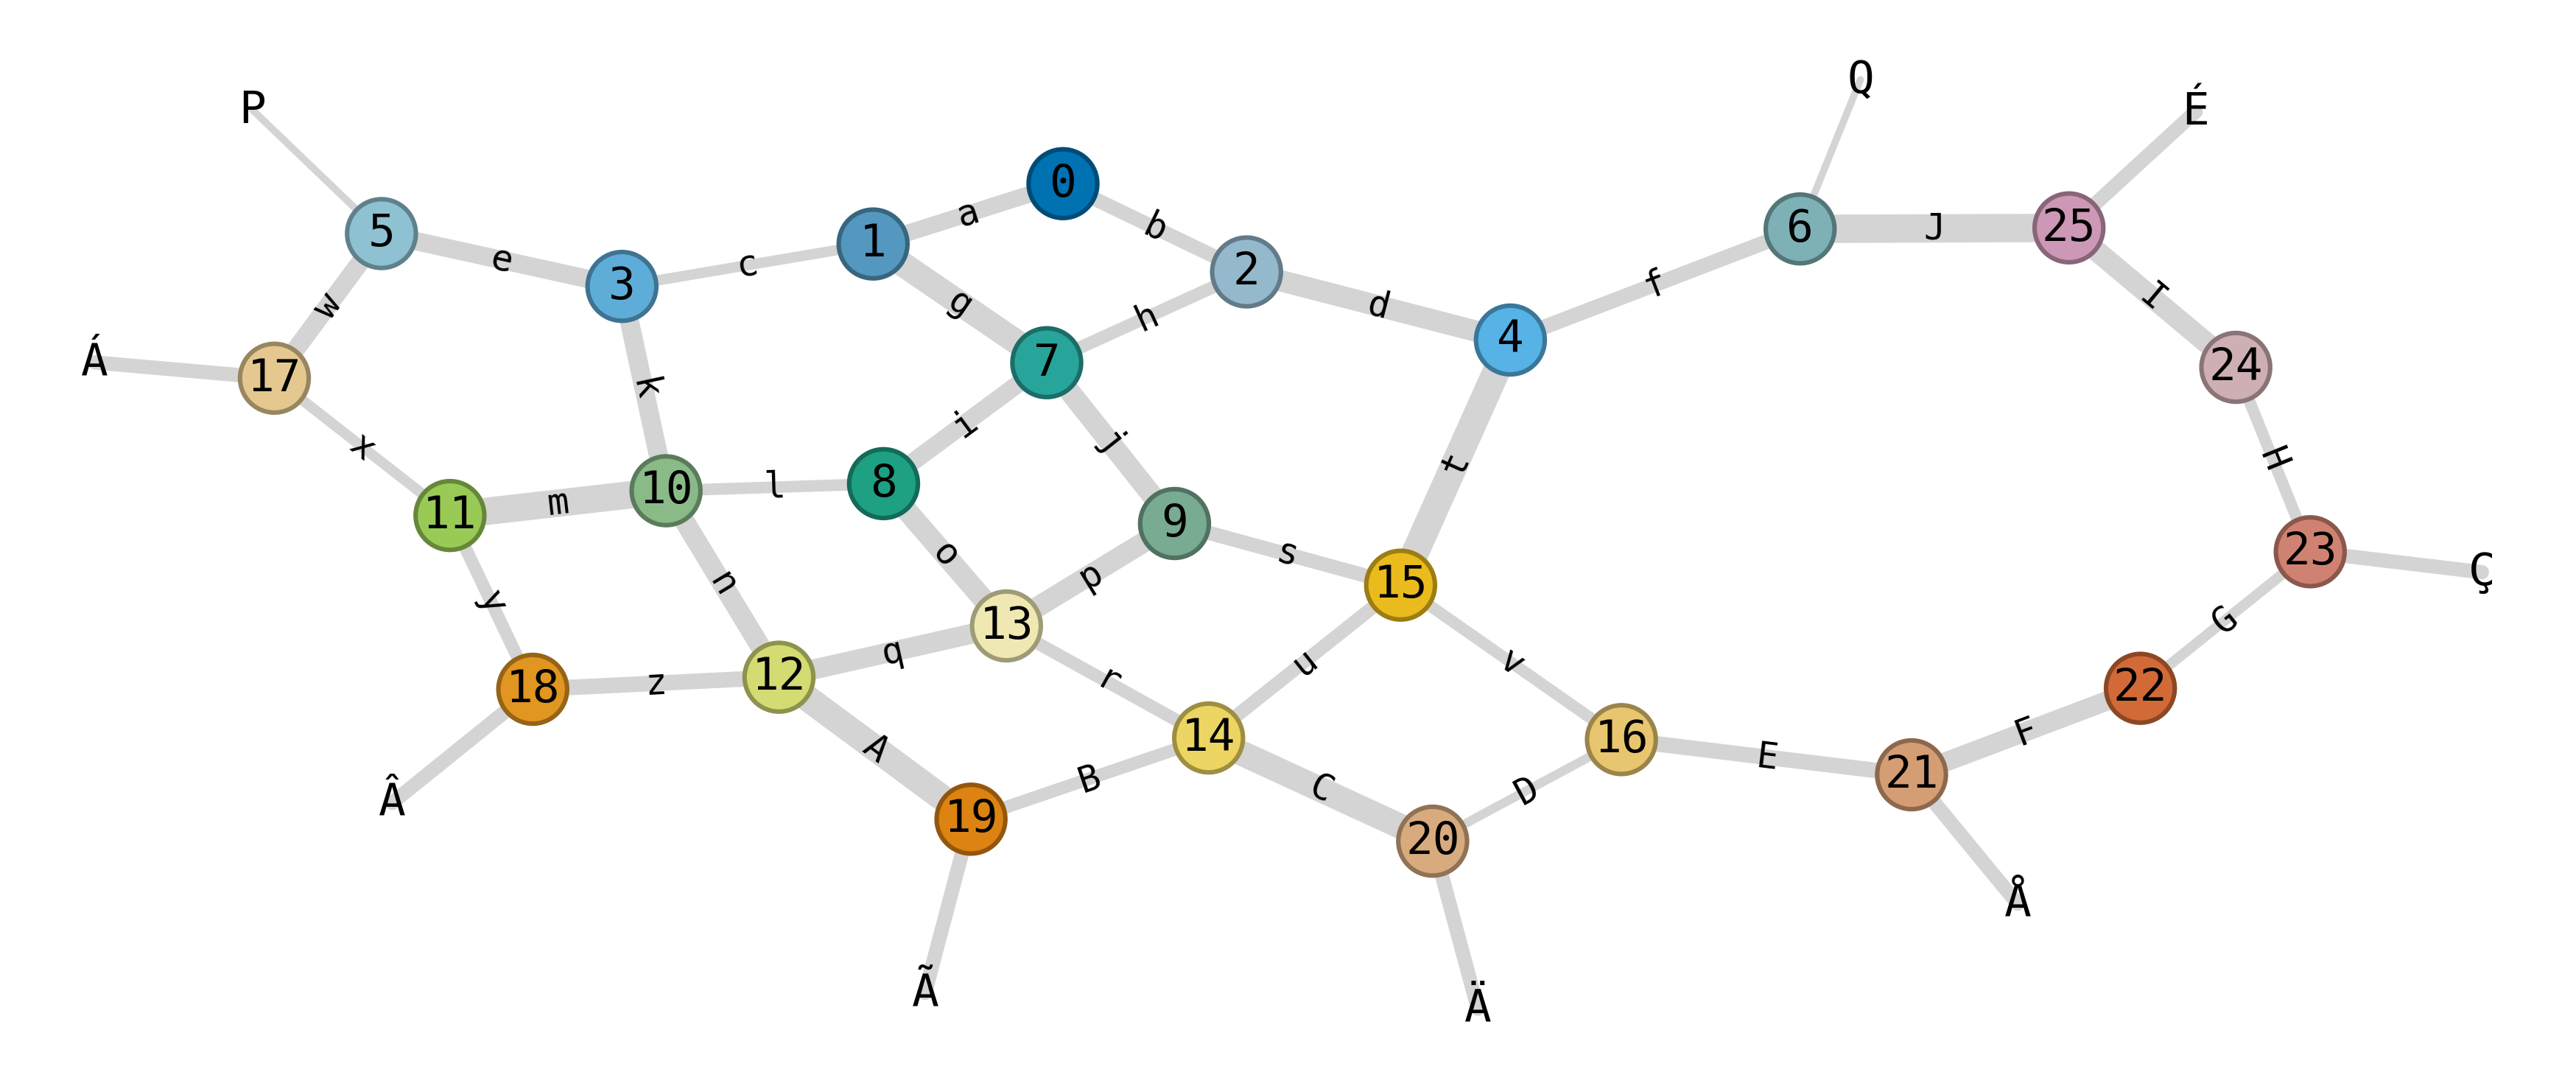

In [21]:
%config InlineBackend.figure_format = 'retina'
import opt_einsum as oe
import einsum_benchmark
import cotengra as ctg
import matplotlib.pyplot as plt

# Set the default DPI to a new value, e.g., 100
plt.rcParams["figure.dpi"] = 220
import einsum_benchmark.util


instance = einsum_benchmark.instances["str_nw_mera_open_26"]

inputs = instance.format_string.split("->")[0].split(",")
output = instance.format_string.split("->")[1]
shapes = [t.shape for t in instance.tensors]
size_dict = ctg.utils.shapes_inputs_to_size_dict(shapes,inputs)

fig,axis = ctg.get_hypergraph(inputs, output, size_dict).plot(
    draw_edge_labels=True,
    edge_color=False,
    fontcolor=(0,0,0),
    figsize=(10,10)
)

Afterwards we can compute meta information with the einsum_benchmark package. 

In [2]:
print(einsum_benchmark.meta.compute_meta_info_of_einsum_instance(
    instance.format_string, 
    instance.tensors
))
# Get three biggest and smallest indices from size_dict
biggest_indices = sorted(size_dict.items(), key=lambda x: x[1], reverse=True)[:3]
smalles_indices = sorted(size_dict.items(), key=lambda x: x[1])[:3]
print(biggest_indices,smalles_indices)

tensors: 26
different_indices: 45
hadamard_products: 0
contraction_edges: 36
contraction_hyperedges: 0
tensors_in_largest_hyperedge: 0
tensors_with_traces_or_diagonals: 0
independent_components: 1
tensors_in_largest_component: 26
smallest_dimension_size: 3
largest_dimension_size: 79
log2(output_size): 25.36
[('J', 79), ('t', 68), ('m', 68)] [('P', 3), ('Q', 3), ('D', 4)]


As we can see the network has $26$ tensors, connected by $45$ indices, there are nine free indices $(P, Q, \dots)$ which leaves $36$ contraction edges $(w,e,k,c, \dots)$. This tensor network has no traces or diagonals and only one component. The dimentsions sizes range from $3$ for index $P$ and $Q$, to $79$ for index $J$. The output is relatively big with an output size of $2^{25.36}$.

## Independent components and diagonals

The following graph has three independent components and an input with an diagonal. We will first look at the whole graph then search and plot the components.

Input with the diagonal 105 śŕZÙZĔ


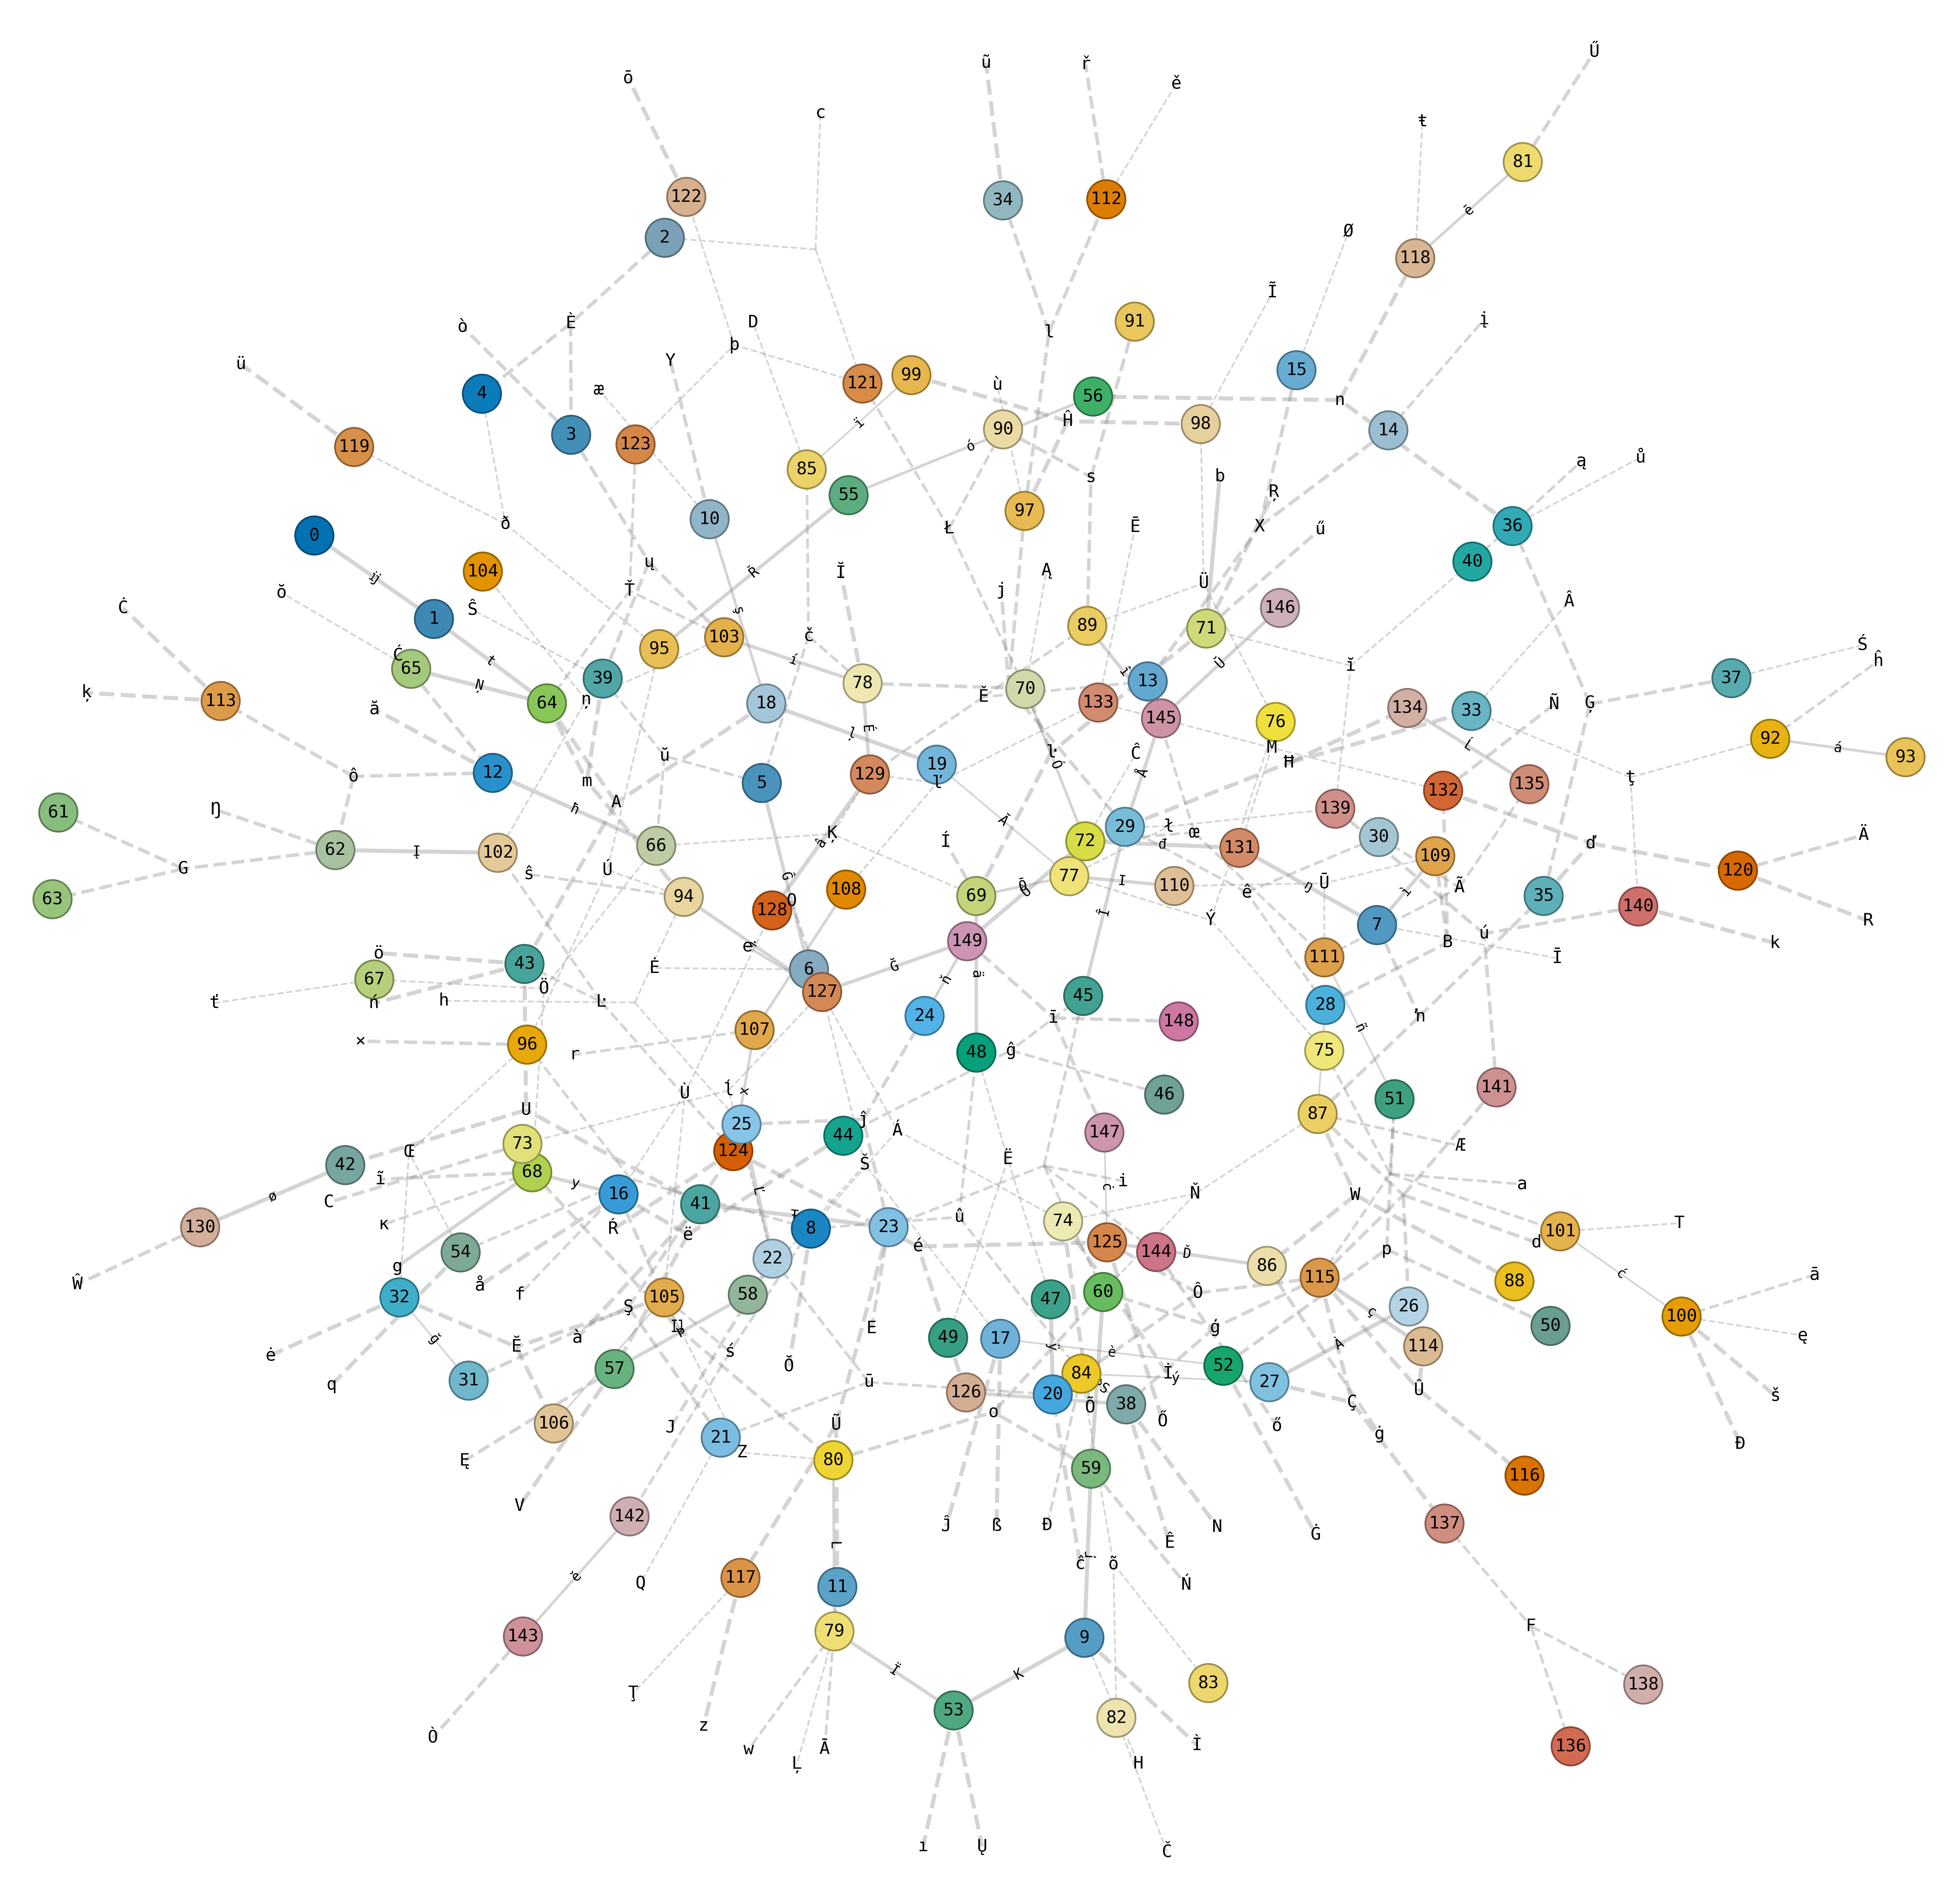

tensors: 150
different_indices: 233
hadamard_products: 2
contraction_edges: 131
contraction_hyperedges: 68
tensors_in_largest_hyperedge: 3
tensors_with_traces_or_diagonals: 1
independent_components: 3
tensors_in_largest_component: 145
smallest_dimension_size: 2
largest_dimension_size: 5
log2(output_size): 16.66


In [25]:
instance = einsum_benchmark.instances["rnd_mixed_04"]

inputs = instance.format_string.split("->")[0].split(",")
output = instance.format_string.split("->")[1]
shapes = [t.shape for t in instance.tensors]
size_dict = ctg.utils.shapes_inputs_to_size_dict(shapes, inputs)

# Find inputs that have the same index twice, print their id as well
for i, input in enumerate(inputs):
    if len(set(input)) != len(input):
        print("Input with the diagonal", i, input)

fig, axis = ctg.get_hypergraph(inputs, output, size_dict).plot(
    draw_edge_labels=True,
    edge_color=False,
    fontcolor=(0, 0, 0),
    figsize=(20, 20),
    layout="kamada_kawai",
)

print(
    einsum_benchmark.meta.compute_meta_info_of_einsum_instance(
        instance.format_string, instance.tensors
    )
)

As we can see this instance has 3 independent components, while 145 of 150 tensors are in the largest component. Thus, the two remaining components are very small.

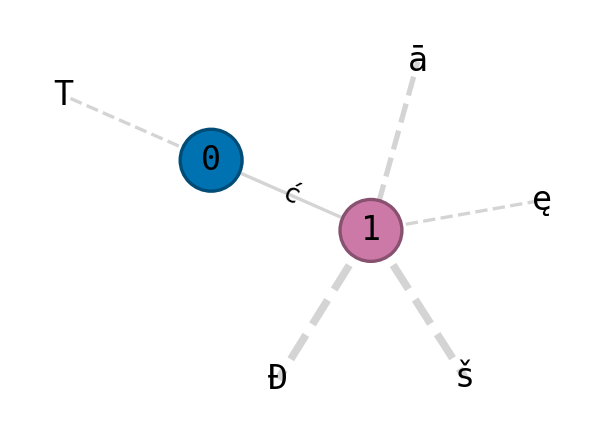

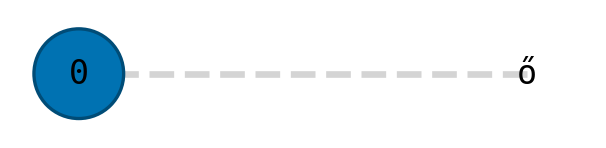

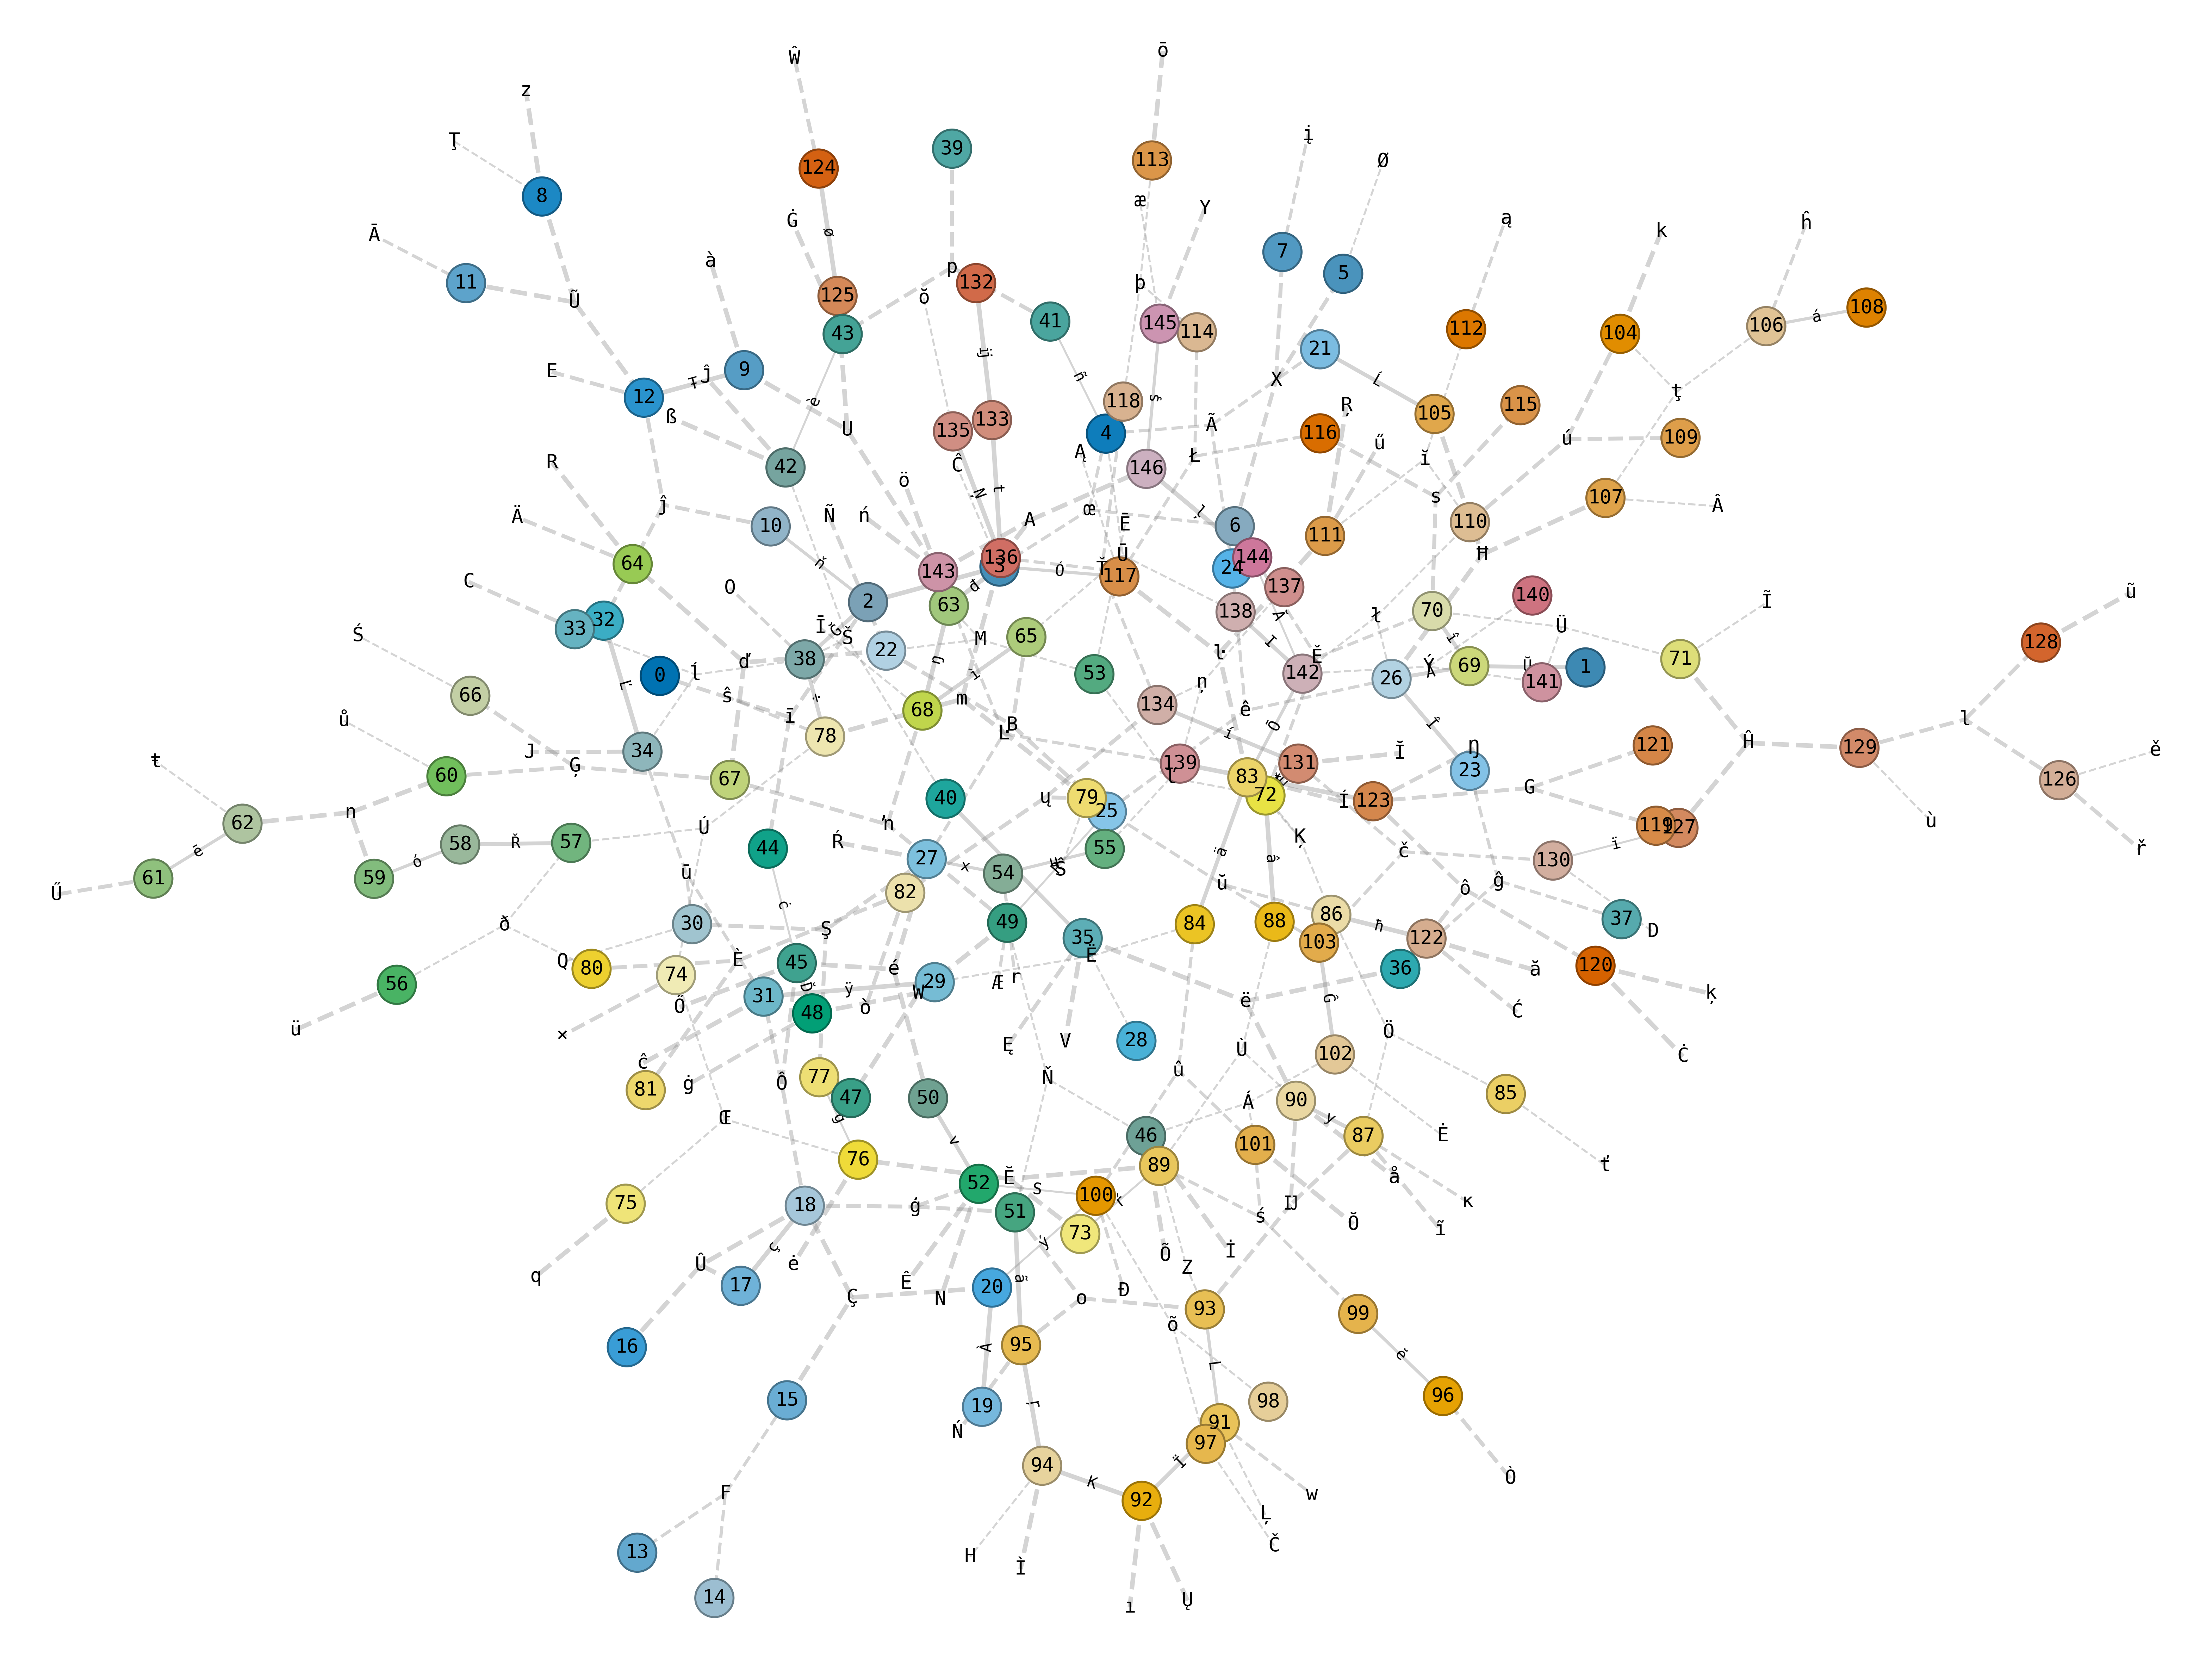

In [28]:
# Find components
components: list[tuple[list,set]] = [([input], set(input).difference(set(output))) for input in inputs]

intersections = True
while intersections:
    intersections = False
    for c1 in components:
        for c2 in components:
            if c1 != c2:
                if c1[1].intersection(c2[1]):
                    intersections = True
                    c1[0].extend(c2[0])
                    c1[1].update(c2[1])
                    components.remove(c2)
                    break


for component in components:
    figsize = (3, 3) if len(component[0]) < 10 else (20, 20)
    if len(component[0]) < 10:
        plt.rcParams["figure.dpi"] = 120
    else:
        plt.rcParams["figure.dpi"] = 200
    c_output = "".join([c for c in output if c in component[1]])
    fig, axis = ctg.get_hypergraph(component[0], c_output, size_dict).plot(
        draw_edge_labels=True,
        edge_color=False,
        fontcolor=(0, 0, 0),
        figsize=figsize,
        layout="kamada_kawai",
    )    